# Model Comparison and Final Model Selection

## Project: Machine Learning-Based U.S. Residential Rental Price Estimation System

This notebook compares the final models developed in the project and selects the model to be used for rental price estimation:

| Model | Developed in |
|---|---|
| Linear Regression / Ridge Regression | `03_Linear_Ridge_Models.ipynb` |
| Random Forest | `03_RandomForest_Thiwanka.ipynb` |
| Gradient Boosting | `04_GradientBoosting_Janeesha.ipynb` |
| Neural Network | `04_NeuralNetwork_Savindu.ipynb` |

All models were trained on `raw_train.csv` and are evaluated on the same 35,920 listings of `raw_test.csv`. Instead of copying the results from the individual notebooks, the predictions of every final model are generated again in this notebook, so that all metrics are calculated in exactly the same way.

## 1. Setup and Data

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

# The models package is located in the project folder
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

SEED = 42

test_df = pd.read_csv(PROJECT_ROOT / "data" / "raw_test.csv")

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

print("Test data:", X_test.shape)

Test data: (35920, 16)


## 2. Loading the Final Models

### 2.1 Saved Model Files

All four final models are saved in the `models` folder. The Neural Network, Gradient Boosting and Ridge Regression files are stored in the repository. The Random Forest file is too large for GitHub, so it is created by training the model (about one minute). Any missing file is created with one command, run from the project folder:

```
python -m models.setup_models
```

The tuned Ridge Regression model (`alpha = 10`) represents the linear models. Its results are almost identical to plain Linear Regression.

In [2]:
model_files = pd.DataFrame([
    {"Model": "Ridge Regression", "File": "models/linear_ridge/artifacts/linear_ridge.joblib"},
    {"Model": "Random Forest", "File": "models/random_forest/artifacts/random_forest.joblib"},
    {"Model": "Gradient Boosting", "File": "models/gradient_boosting/artifacts/gradient_boosting.joblib"},
    {"Model": "Neural Network", "File": "models/neural_network/artifacts/neural_network.pt"}
])

model_files["Available"] = [
    (PROJECT_ROOT / file).exists() for file in model_files["File"]
]
model_files["Size (MB)"] = [
    round((PROJECT_ROOT / file).stat().st_size / 1e6, 2) if available else None
    for file, available in zip(model_files["File"], model_files["Available"])
]

display(model_files)

if not model_files["Available"].all():
    raise FileNotFoundError("Run 'python -m models.setup_models' from the project folder first.")

,Model,File,Available,Size (MB)
0,Ridge Regression,models/linear_ridge/artifacts/linear_ridge.joblib,True,0.01
1,Random Forest,models/random_forest/artifacts/random_forest.j...,True,272.64
2,Gradient Boosting,models/gradient_boosting/artifacts/gradient_bo...,True,0.14
3,Neural Network,models/neural_network/artifacts/neural_network.pt,True,3.66


### 2.2 Generating the Test Predictions

Each model receives the raw test listings and returns predicted prices in dollars. The time needed to predict all 35,920 listings is recorded as well.

In [3]:
from models.gradient_boosting import GradientBoostingRentalPriceModel
from models.linear_ridge import LinearRidgeRentalPriceModel
from models.neural_network import NeuralNetworkRentalPriceModel
from models.random_forest import RandomForestRentalPriceModel

final_models = {
    "Ridge Regression": LinearRidgeRentalPriceModel.load(),
    "Random Forest": RandomForestRentalPriceModel.load(),
    "Gradient Boosting": GradientBoostingRentalPriceModel.load(),
    "Neural Network": NeuralNetworkRentalPriceModel.load()
}

predictions = {}
prediction_seconds = {}

for name, model in final_models.items():
    start_time = time.perf_counter()
    predictions[name] = np.asarray(model.predict(X_test))
    prediction_seconds[name] = time.perf_counter() - start_time

    print(f"{name:<18}: {len(predictions[name]):,} predictions "
          f"in {prediction_seconds[name]:.2f} seconds")

Ridge Regression  : 35,920 predictions in 0.12 seconds


Random Forest     : 35,920 predictions in 0.94 seconds
Gradient Boosting : 35,920 predictions in 0.13 seconds


Neural Network    : 35,920 predictions in 0.15 seconds


## 3. Test Set Performance

### 3.1 Metrics

The same metrics are used for every model:

| Metric | Meaning | Better |
|---|---|---|
| MAE | Average size of the error in dollars | Lower |
| RMSE | Like MAE, but large errors count more heavily | Lower |
| R² | Proportion of the variation in prices explained by the model | Higher |
| Median AE | Error of the typical listing; half of the predictions are closer than this | Lower |
| Within \$100 / \$200 | Share of listings predicted within \$100 or \$200 of the actual price | Higher |

The last column of the table shows the test MAE reported in each model's own notebook. It is used to check that the models were loaded correctly.

In [4]:
# Test MAE reported in the individual notebooks
reported_mae = {
    "Ridge Regression": 242.01,
    "Random Forest": 161.40,
    "Gradient Boosting": 229.54,
    "Neural Network": 149.48
}


def evaluate(y_true, y_pred):
    errors = np.abs(y_true - y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Median AE": median_absolute_error(y_true, y_pred),
        "Within $100 (%)": (errors <= 100).mean() * 100,
        "Within $200 (%)": (errors <= 200).mean() * 100
    }


test_results = pd.DataFrame({
    name: evaluate(y_test, prediction) for name, prediction in predictions.items()
}).T

test_results["Reported MAE"] = pd.Series(reported_mae)
test_results = test_results.sort_values("MAE")

print("Test set performance (35,920 listings):")
display(test_results.round({
    "MAE": 2, "RMSE": 2, "R2": 4, "Median AE": 2,
    "Within $100 (%)": 1, "Within $200 (%)": 1, "Reported MAE": 2
}))

Test set performance (35,920 listings):


,MAE,RMSE,R2,Median AE,Within $100 (%),Within $200 (%),Reported MAE
Neural Network,149.48,274.96,0.8293,79.29,57.9,78.9,149.48
Random Forest,161.40,301.84,0.7943,82.59,56.1,76.6,161.40
Gradient Boosting,229.54,381.75,0.6710,142.50,37.7,63.4,229.54
Ridge Regression,242.01,399.40,0.6399,147.02,36.5,61.4,242.01


**Interpretation.**

- **The models were reproduced correctly.** The MAE calculated here matches the MAE reported in each model's notebook for all four models. The comparison is therefore based on the same models and the same test listings.
- **The Neural Network is the most accurate model on every metric.** It has the lowest MAE (\$149.48), the lowest RMSE (\$274.96), the highest R² (0.8293), the lowest median error (\$79.29) and the highest share of listings predicted within \$100 and \$200.
- **The Random Forest is a close second.** Its median error (\$82.59) and its share of listings within \$100 (56.1%) are close to those of the Neural Network. The gap is larger in RMSE (\$301.84 against \$274.96), which shows that the Neural Network mainly makes fewer *large* errors.
- **Gradient Boosting and Ridge Regression are clearly weaker.** They explain 67% and 64% of the variation in prices, compared with about 80% for the two best models, and their MAE is about \$80 to \$90 higher. Ridge Regression can only represent linear relationships. The Gradient Boosting configuration uses shallow trees (maximum depth 4) and 150 boosting rounds, which most likely limits how much fine local detail it can capture.

### 3.2 Visual Comparison

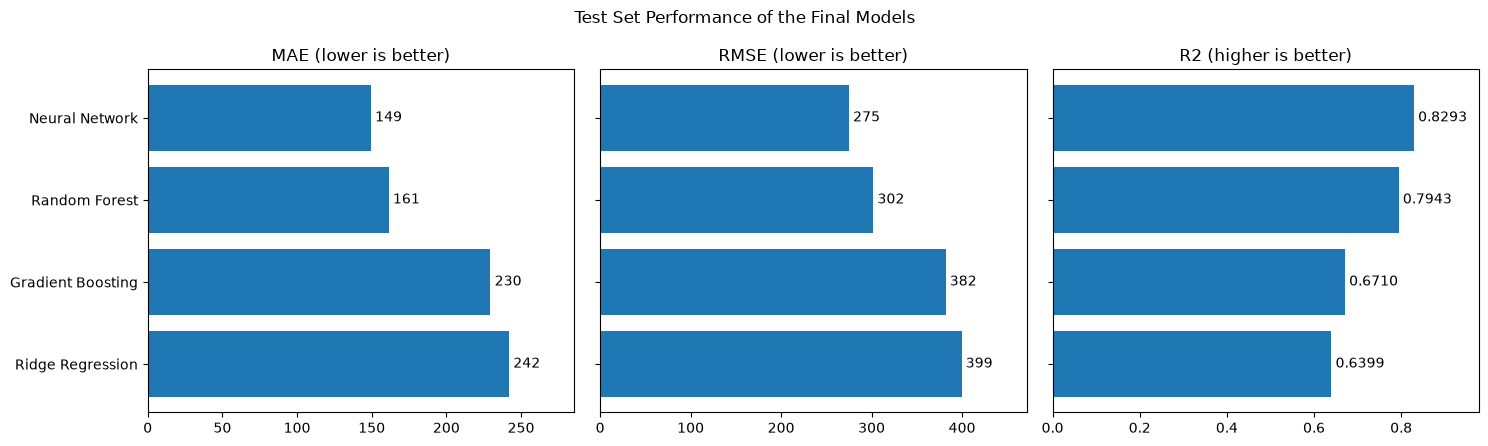

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_order = test_results.index[::-1]

for axis, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    values = test_results.loc[plot_order, metric]
    bars = axis.barh(plot_order, values)
    axis.bar_label(bars, fmt="%.4f" if metric == "R2" else "%.0f", padding=3)
    axis.set_title(f"{metric} ({'higher' if metric == 'R2' else 'lower'} is better)")
    axis.set_xlim(0, values.max() * 1.18)

axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

plt.suptitle("Test Set Performance of the Final Models")
plt.tight_layout()
plt.show()

## 4. Cross-Validation Results

The test set gives one estimate per model. The cross-validation results reported in the individual notebooks show whether the same ranking holds on the training data. They were not calculated with the same number of folds, so they are compared by ranking and not by exact values.

| Model | Folds | Source |
|---|---|---|
| Ridge Regression | 5 (used to select `alpha` on the log scale; no results in dollars) | `03_Linear_Ridge_Models.ipynb` |
| Random Forest | 3 | `03_RandomForest_Thiwanka.ipynb` |
| Gradient Boosting | 5 | `04_GradientBoosting_Janeesha.ipynb` |
| Neural Network | 3 (same folds as the Random Forest) | `04_NeuralNetwork_Savindu.ipynb` |

In [6]:
# Mean cross-validation results of the selected configurations,
# as reported in the individual notebooks
cv_results = pd.DataFrame({
    "Folds": {"Random Forest": 3, "Gradient Boosting": 5, "Neural Network": 3},
    "CV MAE": {"Random Forest": 172.01, "Gradient Boosting": 231.69, "Neural Network": 163.27},
    "CV RMSE": {"Random Forest": 316.11, "Gradient Boosting": 386.32, "Neural Network": 293.00},
    "CV R2": {"Random Forest": 0.7794, "Gradient Boosting": 0.6706, "Neural Network": 0.8105}
}).sort_values("CV MAE")

print("Mean cross-validation results:")
display(cv_results)

Mean cross-validation results:


,Folds,CV MAE,CV RMSE,CV R2
Neural Network,3,163.27,293.00,0.8105
Random Forest,3,172.01,316.11,0.7794
Gradient Boosting,5,231.69,386.32,0.6706


**Interpretation.** The ranking on the training data is the same as on the test set: Neural Network, then Random Forest, then Gradient Boosting. The Neural Network and the Random Forest were cross-validated on identical folds, and the Neural Network has a lower mean MAE (\$163.27 against \$172.01) and RMSE (\$293.00 against \$316.11). The ranking is therefore not the result of one particular test split.

## 5. Error by Price Range

The overall metrics can hide differences between models in specific parts of the price range. The test listings are grouped by their actual price, and the MAE of every model is calculated for each group.

MAE by actual price range:


,Listings,Neural Network,Random Forest,Gradient Boosting,Ridge Regression
price,,,,,
Up to $500,767,274.6,299.5,402.8,442.1
"$500-$1,000",13334,95.4,104.3,142.1,150.4
"$1,000-$1,500",12432,122.2,116.5,164.6,172.3
"$1,500-$2,000",5593,166.2,184.3,267.7,283.6
"$2,000-$3,000",2940,294.8,334.2,486.7,514.6
"Above $3,000",854,668.8,838.6,1248.9,1295.2


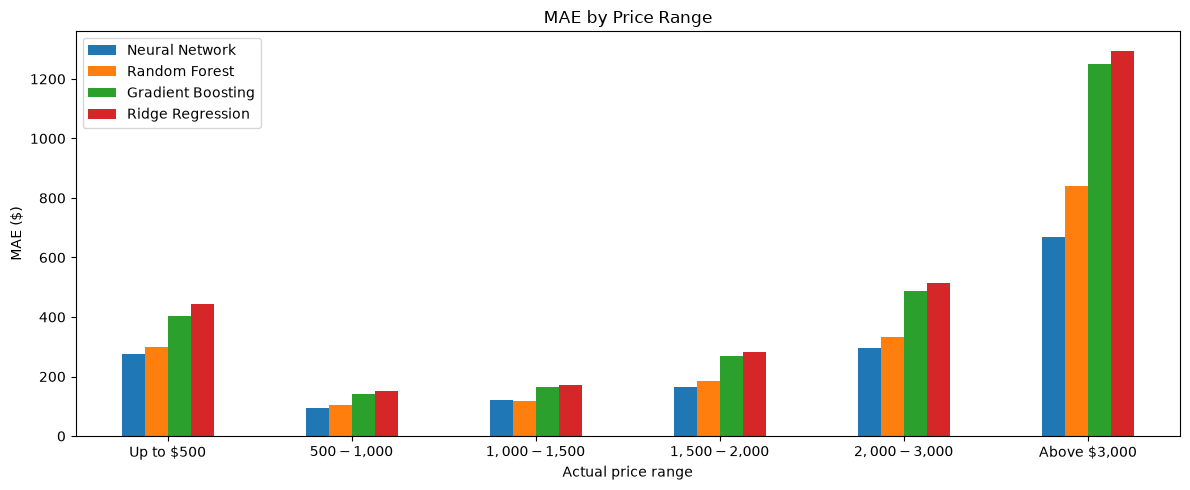

In [7]:
price_bands = pd.cut(
    y_test,
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=["Up to $500", "$500-$1,000", "$1,000-$1,500",
            "$1,500-$2,000", "$2,000-$3,000", "Above $3,000"]
)

band_mae = pd.DataFrame({
    name: pd.Series(np.abs(y_test - prediction)).groupby(price_bands, observed=True).mean()
    for name, prediction in predictions.items()
})[test_results.index]

band_mae.insert(0, "Listings", price_bands.value_counts().reindex(band_mae.index))

print("MAE by actual price range:")
display(band_mae.round(1))

band_mae.drop(columns="Listings").plot(kind="bar", figsize=(12, 5))
plt.xlabel("Actual price range")
plt.ylabel("MAE ($)")
plt.title("MAE by Price Range")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation.**

- **All models are most accurate for typical prices** (\$500 to \$1,500) and least accurate at the extremes. Listings above \$3,000 and below \$500 are the hardest to predict for every model.
- **The Neural Network has the lowest MAE in five of the six price ranges.** The Random Forest is slightly better only between \$1,000 and \$1,500 (\$116.5 against \$122.2).
- **The advantage of the Neural Network grows with the price.** Between \$2,000 and \$3,000 its MAE is \$295 against \$334 for the Random Forest, and above \$3,000 it is \$669 against \$839 (20% lower). This agrees with its lower RMSE: it handles the expensive listings, where errors are largest in dollars, better than the other models.
- **Gradient Boosting and Ridge Regression** have errors of more than \$1,200 above \$3,000, roughly twice those of the Neural Network.

## 6. Is the Difference Between the Two Best Models Reliable?

The test set is a sample of listings. With another sample, the metrics would be slightly different. A **paired bootstrap** estimates how much the difference between the two best models could vary by chance:

1. Draw 35,920 test listings at random, with replacement.
2. Calculate the MAE and RMSE of both models on this resampled set and record the difference.
3. Repeat 2,000 times.

The middle 95% of the recorded differences forms a 95% confidence interval. The comparison is *paired*: both models are evaluated on the same resampled listings in each repetition, so differences in difficulty between samples affect both models equally. If the interval does not contain zero, the better model is better with high confidence and not just by chance.

In [8]:
best_model, second_model = test_results.index[:2]

errors_best = (y_test - predictions[best_model]).to_numpy()
errors_second = (y_test - predictions[second_model]).to_numpy()

rng = np.random.default_rng(SEED)
n_repeats = 2000
n_listings = len(y_test)

mae_differences = []
rmse_differences = []

for _ in range(n_repeats):
    sample = rng.integers(0, n_listings, n_listings)

    mae_differences.append(
        np.abs(errors_second[sample]).mean() - np.abs(errors_best[sample]).mean()
    )
    rmse_differences.append(
        np.sqrt((errors_second[sample] ** 2).mean()) - np.sqrt((errors_best[sample] ** 2).mean())
    )

bootstrap_summary = pd.DataFrame({
    "Observed difference": [
        test_results.loc[second_model, "MAE"] - test_results.loc[best_model, "MAE"],
        test_results.loc[second_model, "RMSE"] - test_results.loc[best_model, "RMSE"]
    ],
    "95% CI lower": [np.percentile(mae_differences, 2.5), np.percentile(rmse_differences, 2.5)],
    "95% CI upper": [np.percentile(mae_differences, 97.5), np.percentile(rmse_differences, 97.5)],
    "Repetitions where the best model wins (%)": [
        np.mean(np.array(mae_differences) > 0) * 100,
        np.mean(np.array(rmse_differences) > 0) * 100
    ]
}, index=["MAE", "RMSE"])

print(f"Difference: {second_model} minus {best_model} (positive = {best_model} is better)")
display(bootstrap_summary.round(2))

Difference: Random Forest minus Neural Network (positive = Neural Network is better)


,Observed difference,95% CI lower,95% CI upper,Repetitions where the best model wins (%)
MAE,11.92,10.17,13.69,100.0
RMSE,26.88,20.65,33.20,100.0


**Interpretation.** On the test set, the MAE of the Random Forest is \$11.92 higher than that of the Neural Network, with a 95% confidence interval from \$10.17 to \$13.69. For RMSE, the difference is \$26.88 (95% confidence interval from \$20.65 to \$33.20). Neither interval contains zero, and the Neural Network has the lower error in all 2,000 resampled test sets. The advantage of the Neural Network is therefore reliable and not the result of chance in the selection of the test listings.

## 7. Practical Considerations

Accuracy is the main criterion, but a model must also be usable. The table summarizes practical properties of each model.

In [9]:
practical = pd.DataFrame({
    "Test MAE": test_results["MAE"].round(2),
    "Model file (MB)": model_files.set_index("Model")["Size (MB)"],
    "Prediction time for the test set (s)": pd.Series(prediction_seconds).round(2),
    "Interpretability": {
        "Ridge Regression": "High: one coefficient per feature",
        "Random Forest": "Medium: feature importance",
        "Gradient Boosting": "Medium: feature importance",
        "Neural Network": "Low: permutation importance only"
    },
    "Training hardware": {
        "Ridge Regression": "CPU, a few seconds",
        "Random Forest": "CPU, about 1 minute",
        "Gradient Boosting": "CPU",
        "Neural Network": "GPU recommended, about 1.5 minutes on GPU"
    }
}).loc[test_results.index]

display(practical)

,Test MAE,Model file (MB),Prediction time for the test set (s),Interpretability,Training hardware
Neural Network,149.48,3.66,0.15,Low: permutation importance only,"GPU recommended, about 1.5 minutes on GPU"
Random Forest,161.40,272.64,0.94,Medium: feature importance,"CPU, about 1 minute"
Gradient Boosting,229.54,0.14,0.13,Medium: feature importance,CPU
Ridge Regression,242.01,0.01,0.12,High: one coefficient per feature,"CPU, a few seconds"


**Interpretation.**

- **Prediction speed is not a deciding factor.** Every model predicts all 35,920 test listings in less than one second.
- **Model size.** The Random Forest file is about 273 MB, because it stores 200 deep trees, and it is too large to be stored on GitHub. The Neural Network needs 3.7 MB, and the Gradient Boosting and Ridge models less than 0.2 MB. A small file is easier to store, share and deploy.
- **Interpretability.** Ridge Regression is the easiest model to explain, because each feature has one coefficient. The Neural Network is the hardest; its behaviour can only be described indirectly, for example with permutation importance.
- **Hardware.** The Neural Network benefits from a GPU for training. Predictions run on an ordinary CPU and give the same results.

## 8. Final Model Selection

The model is selected on predictive accuracy on unseen data, which is the purpose of the system, and checked against the practical considerations.

| Criterion | Ridge Regression | Gradient Boosting | Random Forest | Neural Network |
|---|---|---|---|---|
| Test MAE | \$242.01 | \$229.54 | \$161.40 | **\$149.48** |
| Test RMSE | \$399.40 | \$381.75 | \$301.84 | **\$274.96** |
| Test R² | 0.6399 | 0.6710 | 0.7943 | **0.8293** |
| Cross-validation rank | – | 3 | 2 | **1** |
| Model file | 0.01 MB | 0.14 MB | 272.64 MB | 3.66 MB |
| Interpretability | High | Medium | Medium | Low |

### Selected model: Neural Network

The **Neural Network** (`04_NeuralNetwork_Savindu.ipynb`, configuration `Tuned_5`) is selected as the final model for rental price estimation:

1. It is the most accurate model on every test metric: MAE \$149.48, RMSE \$274.96 and R² 0.8293.
2. Its advantage over the second-best model, the Random Forest, is reliable: the bootstrap confidence intervals of the differences in MAE and RMSE exclude zero.
3. The ranking is confirmed by cross-validation on the training data, on the same folds as the Random Forest.
4. It is the most accurate model in five of the six price ranges, and its advantage is largest for expensive listings.
5. It is practical to use: the saved model is 3.7 MB and predicts quickly on an ordinary CPU.

Compared with the Random Forest, the Neural Network reduces the average error by \$11.92 per listing (7.4%) and the RMSE by 8.9%.

**Limitations.** The Neural Network is the least interpretable model, and, like all models, it is least accurate for very cheap and very expensive listings. Where a simple explanation of each prediction is more important than accuracy, the Random Forest is the best alternative: it is the second most accurate model and provides feature importances directly.